# Homework 02
L. N. Jakubczyk

DATA 71200 | Spring 2026

# Simple Regression Models: Framingham Heart Study

For this homework I'm fitting four simple regression models on the Framingham data, each with a different single predictor and cigarettes per day as the outcome. The goal is to compare how much variance each predictor explains on its own using R-squared.

## How to run this notebook

Open in Jupyter Notebook and run all cells. Dependencies are installed automatically by the first cell.

Model claude-sonnet-4-6 used for boilerplate setup only; analysis and interpretation are my own.

## 1. Setup and Data Loading

Loading the libraries I need and reading in the dataset. The Excel file has no header row so I have to assign column names manually from the codebook. I also drop any rows with missing values upfront so that all four models are fit on the same sample and the R-squared values are directly comparable.

In [9]:
import subprocess, sys

# install dependencies if missing
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                       "pandas", "numpy", "matplotlib", "seaborn",
                       "scikit-learn", "openpyxl"])

import pandas as pd                                  # data
import numpy as np                                   # numerical
import matplotlib.pyplot as plt                      # plotting
import seaborn as sns                                # heatmap
from sklearn.linear_model import LinearRegression    # OLS regression

# the Excel file has no header row, so without header=None pandas would
# treat the first row of data as column names
df = pd.read_excel("02_Framingham-Heart-Study-Brief.xlsx", header=None)

# assign column names from the codebook
df.columns = ["Sex", "Age", "Education", "CigsPerDay", "BMI"]

# drop any row that has at least one missing value
# doing this once here means all four models will run on the same 4090 rows,
# so R-squared is comparable across models
df = df.dropna()
print("Shape (complete cases):", df.shape)
print("(Rows with missing values dropped so regression is on the same N.)")
print(df.head(10))

# descriptive stats to check the data looks reasonable before modeling
df.describe()

Shape (complete cases): (4090, 5)
(Rows with missing values dropped so regression is on the same N.)
   Sex  Age  Education  CigsPerDay    BMI
0    1   39        4.0         0.0  26.97
1    0   43        1.0         0.0  27.78
2    0   65        1.0         0.0  19.83
3    0   60        1.0         0.0  27.49
4    0   41        3.0         0.0  22.72
5    1   57        1.0         0.0  28.09
6    0   52        3.0         0.0  26.36
7    0   61        2.0         0.0  24.79
8    1   45        4.0         0.0  28.40
9    0   39        1.0         0.0  20.99



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3.13 install --upgrade pip


,Sex,Age,Education,CigsPerDay,BMI
count,4090.000000,4090.000000,4090.000000,4090.000000,4090.000000
mean,0.427873,49.545477,1.979218,9.050856,25.776257
std,0.494831,8.559061,1.020124,11.935912,4.084651
min,0.000000,32.000000,1.000000,0.000000,15.540000
25%,0.000000,42.000000,1.000000,0.000000,23.052500
50%,0.000000,49.000000,2.000000,0.000000,25.380000
75%,1.000000,56.000000,3.000000,20.000000,27.990000
max,1.000000,70.000000,4.000000,70.000000,56.800000


## 2. Correlation Matrix of the Five Variables

Before running the regressions I want to look at the pairwise correlations. This is useful because in simple regression R-squared equals the squared Pearson correlation, so the correlation matrix basically already tells me which model is going to win.

Correlation matrix (Pearson):


,Sex,Age,Education,CigsPerDay,BMI
Sex,1.000,-0.028,0.016,0.320,0.081
Age,-0.028,1.000,-0.164,-0.193,0.136
Education,0.016,-0.164,1.000,0.008,-0.138
CigsPerDay,0.320,-0.193,0.008,1.000,-0.090
BMI,0.081,0.136,-0.138,-0.090,1.000


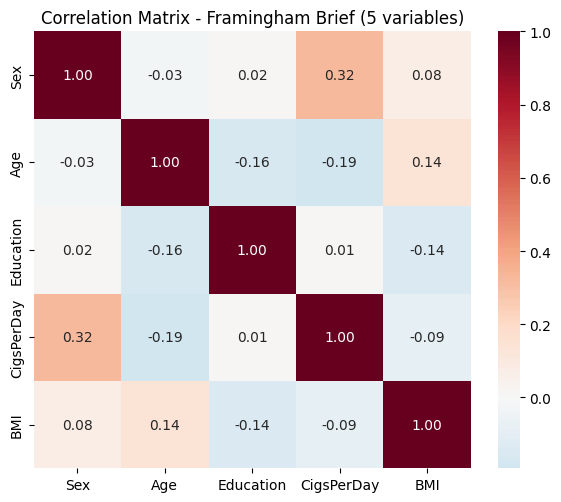

In [10]:
# df.corr() computes pairwise Pearson correlations for all numeric columns
corr = df.corr()
print("Correlation matrix (Pearson):")
display(corr.round(3))

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    corr,
    annot=True,       # print the correlation value in each cell
    fmt=".2f",        # two decimal places
    cmap="RdBu_r",    # blue = positive correlation, red = negative
    center=0,         # anchor the color scale at zero so white = no correlation
    square=True,
    ax=ax
)
plt.title("Correlation Matrix - Framingham Brief (5 variables)")
plt.tight_layout()
plt.show()

## 3. Simple Regression Models

Here I fit four separate OLS models using sklearn, one for each predictor. I define y once since the outcome is the same across all models.

In [11]:
# Model 1: Sex (0=Female, 1=Male)
X1 = df[["Sex"]]      # double brackets give a 2D array, which sklearn requires for X
y = df["CigsPerDay"]  # outcome variable, single brackets is fine here (1D series)

m1 = LinearRegression().fit(X1, y)

# .intercept_ is the predicted CigsPerDay when Sex=0 (i.e. for females)
# .coef_[0] is the change in CigsPerDay for a one-unit increase in Sex (female to male)
# .score() returns R-squared
print("Model 1: CigsPerDay ~ Sex")
print(f"  Intercept: {m1.intercept_:.4f}, Coef(Sex): {m1.coef_[0]:.4f}, R2: {m1.score(X1, y):.4f}")
print()

Model 1: CigsPerDay ~ Sex
  Intercept: 5.7474, Coef(Sex): 7.7206, R2: 0.1024



In [12]:
# Model 2: Age (continuous, 32-70)
# y is already defined above and stays the same for all four models
X2 = df[["Age"]]
m2 = LinearRegression().fit(X2, y)

# negative coefficient would mean older participants smoke fewer cigarettes on average
print("Model 2: CigsPerDay ~ Age")
print(f"  Intercept: {m2.intercept_:.4f}, Coef(Age): {m2.coef_[0]:.4f}, R2: {m2.score(X2, y):.4f}")
print()

Model 2: CigsPerDay ~ Age
  Intercept: 22.4089, Coef(Age): -0.2696, R2: 0.0374



In [13]:
# Model 3: Education (ordinal 1-4, where 1=lowest and 4=highest)
# treating it as continuous here, which is a simplification but common for ordinal vars
X3 = df[["Education"]]
m3 = LinearRegression().fit(X3, y)

# I'd expect a negative coefficient (more education, less smoking)
# but the actual result is worth checking given the era of the data
print("Model 3: CigsPerDay ~ Education")
print(f"  Intercept: {m3.intercept_:.4f}, Coef(Education): {m3.coef_[0]:.4f}, R2: {m3.score(X3, y):.4f}")
print()

Model 3: CigsPerDay ~ Education
  Intercept: 8.8581, Coef(Education): 0.0974, R2: 0.0001



In [14]:
# Model 4: BMI (continuous)
X4 = df[["BMI"]]
m4 = LinearRegression().fit(X4, y)

print("Model 4: CigsPerDay ~ BMI")
print(f"  Intercept: {m4.intercept_:.4f}, Coef(BMI): {m4.coef_[0]:.4f}, R2: {m4.score(X4, y):.4f}")

Model 4: CigsPerDay ~ BMI
  Intercept: 15.8469, Coef(BMI): -0.2637, R2: 0.0081


## 4. Comparison Table: R-squared for Each Model

Putting all four R-squared values in one table so I can rank the models. I'd expect the ranking to match what the correlation matrix showed earlier.

In [15]:
# pull R-squared from each fitted model
r2_scores = [m1.score(X1, y), m2.score(X2, y), m3.score(X3, y), m4.score(X4, y)]

r2_table = pd.DataFrame({
    "Model": [
        "CigsPerDay ~ Sex",
        "CigsPerDay ~ Age",
        "CigsPerDay ~ Education",
        "CigsPerDay ~ BMI",
    ],
    "R2": r2_scores,
    "R2 (%)": [f"{r*100:.2f}%" for r in r2_scores],  # percentage form is easier to read
})

# sort descending so the best model is at the top
r2_table = r2_table.sort_values("R2", ascending=False).reset_index(drop=True)
display(r2_table)

# grab the top row to print the winner cleanly
best = r2_table.iloc[0]
print(f"Best single-predictor model: {best['Model']} (R2 = {best['R2']:.4f}, {best['R2 (%)']})")

,Model,R2,R2 (%)
0,CigsPerDay ~ Sex,0.102447,10.24%
1,CigsPerDay ~ Age,0.037378,3.74%
2,CigsPerDay ~ BMI,0.008141,0.81%
3,CigsPerDay ~ Education,0.000069,0.01%


Best single-predictor model: CigsPerDay ~ Sex (R2 = 0.1024, 10.24%)


## 5. Interpretation

Sex is the strongest predictor at R-squared = 0.10, accounting for about 10% of the variance in daily cigarette use. Age comes in at 3.74%, BMI under 1%, and Education is essentially zero at 0.01%. The Education coefficient is also positive, which runs counter to the expected direction.

The Sex result needs historical context to interpret properly. The Framingham Heart Study is a longitudinal cohort study that began in 1948, and the original cohort data reflects smoking patterns from the postwar decades. During that period, smoking was deeply tied to gender norms in ways it no longer is, and men smoked substantially more than women. Sex is a real predictor in this sample, but it is capturing a social pattern specific to that historical moment rather than a biological signal. The coefficient would look quite different in contemporary data.

The Education finding makes sense for the same reason. The inverse relationship between education and smoking that shows up consistently in modern research is largely a product of shifting health literacy and changing social norms around tobacco. In the postwar period, educated Americans smoked as much as anyone else, and that gradient had not yet formed. That is probably why the coefficient is near zero and pointing the wrong way.

The uniformly low R-squared values across all four models are the real takeaway. These are distal demographic variables, and smoking is an addiction whose proximal drivers simply are not in this dataset: household smoking behavior, peer influence, stress, nicotine dependence, prior use history. The poor model fit is not a methodological problem. It reflects the limits of demographic prediction for a behavioral outcome like addiction.